# Temporal XGBoost v2 — RSU Tier · Sybil Detector with RSSI Evidence

## What this notebook does
This is the **RSU-tier half** of the Temporal Analyzer in DSMF-SDVEN.

An RSU has a **privileged, regional vantage point**: it passively overhears every V2V beacon
in its coverage area AND runs RSSI-based position verification. An OBU only hears its immediate
neighbors; an RSU hears everything in a 300–500m radius simultaneously.

This notebook trains an XGBoost classifier on RSU-observable features to produce:
- **p_bar_temp(v_i)** = 1 − p_legitimate = per-identity Sybil suspicion score
- This feeds into the RSU-tier ensemble: `y_hat_ens = λ1*y_hat_i + λ2*p_bar_temp + λ3*p_bar_RSSI`

## What changed from v1 and why

| Issue in v1 | Fix in v2 | Why |
|---|---|---|
| Mixed V2V + RSU flows | **Filter to `receiver_role == "rsu_edge"` only** | XGBoost must only see RSU-observable data |
| No cross-identity window context | **Global context features per window** | RSU sees all claimed IDs simultaneously — OBU cannot |
| No hyperparameter sweep | **max_depth grid + sensitivity analysis** | Paper §4.10.5 requires val MCC selection |

## Why XGBoost at the RSU tier (not GRU)
- Trees handle **tabular aggregate features** better than recurrent models
- XGBoost is trained centrally — no FL compatibility needed at RSU tier
- RSU sees **5-second aggregate windows** not raw beacon sequences (different data format)
- The RSU's RSSI verification logs produce tabular features (counts, rates, flags) ideal for trees

## NS-3 alignment
NS-3 logs RSU receptions in `communication_log.csv` with `receiver_role == "rsu_edge"`.
The RSU also writes `rsu_regional_awareness_log.csv` and `rsu_vehicle_observation_rows_log.csv`
with RSSI verification results — this notebook merges all three.

## 1. Configuration · RSU Tier

In [12]:
import os, json, warnings, random
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

BASE_DIR  = "/home/sdvn_defense_sybil/35_sybil_attack_project/ns-allinone-3.35/ns-3.35/sybil-attack"
DATA_DIR  = os.path.join(BASE_DIR, "datasets/seq_run3")
COMM_LOG  = os.path.join(DATA_DIR, "communication_log.csv")
ATTACKERS = os.path.join(DATA_DIR, "sybil_attackers.csv")

# RSU awareness logs (written by NS-3 RSU nodes)
RSU_REGIONAL = os.path.join(DATA_DIR, "rsu_regional_awareness_log.csv")
RSU_OBSROWS  = os.path.join(DATA_DIR, "rsu_vehicle_observation_rows_log.csv")

OUTPUT_DIR          = os.path.join(BASE_DIR, "ml/outputs")
OUTPUT_TEMPORAL_DIR = os.path.join(BASE_DIR, "ml/outputs_temporal")
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(OUTPUT_TEMPORAL_DIR, exist_ok=True)

ATTACK_TYPE_TO_CLASS = {0: "legitimate", 1: "outsider", 2: "sim", 3: "nonsim", 4: "indirect"}
ATTACK_CLASSES = ["legitimate", "outsider", "sim", "nonsim", "indirect"]
CLASS_TO_IDX   = {c: i for i, c in enumerate(ATTACK_CLASSES)}
IDX_TO_CLASS   = {i: c for c, i in CLASS_TO_IDX.items()}

USE_COLS = [
    "receive_time", "flow", "receiver_role", "receiver_id", "real_node_id", "claimed_node_id",
    "message_type", "sequence_number", "packet_size", "delay",
    "bsm_temporary_id", "bsm_msg_count", "bsm_x", "bsm_y", "bsm_speed", "bsm_heading",
    "attack_type",
]

TEST_SIZE = 0.15
VAL_SIZE  = 0.15 / (1 - TEST_SIZE)   # true 15% of the whole set -> 70:15:15 (val from the 85% train+val remainder)

# RSU-observable flows
RSU_RX_FLOWS = ["v2v_beacon", "v2rsu_report"]

# Windowing — time-based at RSU tier (RSU sees continuous stream, not per-identity sequences)
WINDOW_SIZE_S      = 5.0
WINDOW_STEP_S      = 2.0
MIN_BEACONS_WINDOW = 2

# XGBoost hyperparameter grid (paper §4.10.5 sensitivity analysis)
SWEEP_MAX_DEPTH = [4, 5, 6]
XGB_LR          = 0.05
XGB_N_EST       = 600
XGB_EARLY_STOP  = 30

print("Config loaded.")
print(f"RSU flows: {RSU_RX_FLOWS}")
print(f"Window: {WINDOW_SIZE_S}s size, {WINDOW_STEP_S}s step")

Config loaded.
RSU flows: ['v2v_beacon', 'v2rsu_report']
Window: 10.0s size, 1.0s step


## 2. Load and Label

### Labelling rule (identical to GRU notebook)
`real_node_id != claimed_node_id` → attack class from `attack_type`.
`real_node_id` is used only here — never as a model feature.

In [13]:
def load_single_run(comm_log_path, attackers_path, use_cols=USE_COLS):
    df = pd.read_csv(comm_log_path, usecols=lambda c: (c in use_cols))
    for c in df.select_dtypes("float64").columns:
        df[c] = pd.to_numeric(df[c], downcast="float")
    for c in df.select_dtypes("int64").columns:
        df[c] = pd.to_numeric(df[c], downcast="integer")
    attacker_ids = set()
    if os.path.exists(attackers_path):
        adf = pd.read_csv(attackers_path)
        attacker_ids = set(adf["attacker_node_id"].astype(int).tolist())
    is_mismatch  = (df["real_node_id"] != df["claimed_node_id"])
    phase_class  = df["attack_type"].map(ATTACK_TYPE_TO_CLASS).fillna("legitimate")
    df["attack_class"] = np.where(is_mismatch, phase_class, "legitimate")
    df["is_sybil"]     = (df["attack_class"] != "legitimate").astype(int)
    return df, attacker_ids

raw_df, attacker_ids = load_single_run(COMM_LOG, ATTACKERS)
print("Raw rows:", len(raw_df))
print(raw_df["attack_class"].value_counts())

Raw rows: 9387778
attack_class
legitimate    7352152
sim            964471
outsider       745857
nonsim         227722
indirect        97576
Name: count, dtype: int64


## 3. RSU-Tier Filter and Deduplicate

### What the RSU sees that the OBU cannot
An OBU only hears beacons from immediate neighbors (V2V range ~100–200m).
An RSU has higher antennas, wider coverage (300–500m), and sees all vehicles in its cell.

Most importantly, the RSU can see **multiple claimed_node_ids from the same physical sender**
simultaneously — the cross-identity context that reveals Sybil attacks.

### Filter
Keep only rows where `receiver_role == "rsu_edge"` — beacons the RSU actually received.
This includes both `v2v_beacon` (RSU overhearing V2V traffic) and `v2rsu_report` (direct reports).

### Hard assertion
XGBoost must never see vehicle-only flows. The assertion enforces this architecturally.

In [14]:
BEACON_KEY = ["real_node_id", "claimed_node_id", "bsm_temporary_id", "receive_time"]

def dedup_beacons(df):
    """Collapse broadcast fan-out. observer_count = RSUs that overheard the beacon."""
    dup = (df.groupby(BEACON_KEY)["receiver_id"].nunique()
             .rename("observer_count").reset_index())
    agg_cols = [c for c in df.columns if c not in ["receiver_id", "receiver_role"]]
    b = (df.sort_values("receive_time").groupby(BEACON_KEY, as_index=False)[agg_cols].first())
    b = b.merge(dup, on=BEACON_KEY, how="left")
    return b.sort_values(["claimed_node_id", "receive_time"]).reset_index(drop=True)

rsu_raw = raw_df[(raw_df["receiver_role"] == "rsu_edge")
                 & (raw_df["flow"].isin(RSU_RX_FLOWS))].copy()
print("RSU-received rows:", len(rsu_raw))
print("By flow:\n", rsu_raw["flow"].value_counts())

rsu_beacons = dedup_beacons(rsu_raw)
del raw_df, rsu_raw

# Hard constraint: XGBoost must only see RSU-observable flows
assert set(rsu_beacons["flow"].unique()) <= set(RSU_RX_FLOWS), "RSU tier saw a non-RSU flow!"
print("\nBeacon events after dedup:", len(rsu_beacons))
print("\nRSU-tier class balance:")
print(rsu_beacons["attack_class"].value_counts())

RSU-received rows: 688592
By flow:
 flow
v2v_beacon      686507
v2rsu_report      2085
Name: count, dtype: int64

Beacon events after dedup: 144936

RSU-tier class balance:
attack_class
legitimate    96564
outsider      26052
sim           18574
nonsim         2959
indirect        787
Name: count, dtype: int64


## 4. EDA — RSU Tier

### Why RSU sees nonsim better than OBU
The Non-Simultaneous attacker (nonsim) rotates its claimed_node_id after every beacon.
At the OBU level: each identity appears for 1 beacon → hard to learn.
At the RSU level: the RSU sees ALL these rotating identities simultaneously within its cell.
The cross-identity context features (active_claimed_ids_window, shared_temp_id_count_window)
directly capture this rotation pattern — which is invisible to any single OBU.

In [15]:
print("Distinct claimed_node_id per class (RSU observes all):")
print(rsu_beacons.groupby("attack_class")["claimed_node_id"].nunique())
print("\nBeacons per claimed_node_id, by class:")
print(rsu_beacons.groupby(["attack_class","claimed_node_id"]).size()
                 .groupby("attack_class").describe()[["count","mean","min","max"]])

Distinct claimed_node_id per class (RSU observes all):
attack_class
indirect       40
legitimate    200
nonsim        336
outsider      105
sim           169
Name: claimed_node_id, dtype: int64

Beacons per claimed_node_id, by class:
              count        mean   min     max
attack_class                                 
indirect       40.0   19.675000   1.0    44.0
legitimate    200.0  482.820000  67.0  1427.0
nonsim        336.0    8.806548   1.0    71.0
outsider      105.0  248.114286   8.0   765.0
sim           169.0  109.905325   2.0   474.0


## 5. Build RSU-Tier Windowed Behavioural Features

### Why time-based windows (not count-based) at RSU tier
The GRU uses W=10 count-based windows per `(receiver_id, claimed_node_id)` pair — tracking one
identity's beacon stream as seen by one OBU.

The XGBoost uses **5-second time-based windows over all claimed_node_ids simultaneously**.
This is different because:
- The RSU's power comes from seeing ALL identities at once
- Cross-identity features (how many claimed IDs active, how many share a temp_id) require
  a time window across all identities, not a per-identity beacon count
- Time-based windows align with the RSU's real-time monitoring of its cell

### Features computed per (claimed_node_id, time_window)
31 behavioural features covering:
- **IAT statistics:** mean, std, min, max, entropy of inter-arrival times
- **Identity features:** temp_id churn rate, change count, claimed_id age
- **Mobility:** position variance, speed consistency error, heading std
- **Cross-identity context:** active_claimed_ids_window, shared_temp_id_count — these are
  the features only an RSU can compute (it sees ALL neighbors simultaneously)

In [16]:
def shannon_entropy(values, n_bins=10):
    values = np.asarray(values, dtype=float)
    values = values[~np.isnan(values)]
    if len(values) < 2: return np.nan
    rng = values.max() - values.min()
    if rng <= 1e-12: return 0.0
    counts, _ = np.histogram(values, bins=n_bins, range=(values.min(), values.max()))
    probs = counts / counts.sum(); probs = probs[probs > 0]
    return float(-np.sum(probs * np.log2(probs)))

def build_global_context(b_sorted, window_size, window_step):
    """Cross-identity context per global time window — only computable at RSU tier."""
    t   = b_sorted["receive_time"].values
    cid = b_sorted["claimed_node_id"].values
    tid = b_sorted["bsm_temporary_id"].values
    first_seen = b_sorted.groupby("claimed_node_id")["receive_time"].min().values
    t0, t1 = float(t.min()), float(t.max())
    starts = np.arange(np.floor(t0), t1 + window_step, window_step)
    ctx = {}
    for s in starts:
        e = s + window_size
        lo = np.searchsorted(t, s); hi = np.searchsorted(t, e)
        if hi <= lo:
            ctx[round(float(s),6)] = (0,0,0,0,0); continue
        sub = pd.DataFrame({"cid": cid[lo:hi], "tid": tid[lo:hi]})
        claimed_per_temp = sub.groupby("tid")["cid"].nunique()
        new_ids = int(((first_seen >= s) & (first_seen < e)).sum())
        ctx[round(float(s),6)] = (
            int(sub["cid"].nunique()), int(sub["tid"].nunique()),
            int((claimed_per_temp > 1).sum()),
            int(claimed_per_temp.max()) if len(claimed_per_temp) else 0, new_ids)
    return ctx, starts

def build_feature_table(beacons_df, window_size=WINDOW_SIZE_S, window_step=WINDOW_STEP_S,
                        min_beacons=MIN_BEACONS_WINDOW):
    b = beacons_df.sort_values("receive_time").reset_index(drop=True)
    context, starts = build_global_context(b, window_size, window_step)
    first_seen_global = b.groupby("claimed_node_id")["receive_time"].min().to_dict()
    rows = []
    for cidv, g in b.groupby("claimed_node_id"):
        g = g.sort_values("receive_time").reset_index(drop=True)
        gt0, gt1 = g["receive_time"].min(), g["receive_time"].max()
        fs = first_seen_global[cidv]
        rel = starts[(starts <= gt1) & (starts + window_size > gt0)]
        prev_end = None
        for s in rel:
            e = s + window_size
            w = g[(g["receive_time"] >= s) & (g["receive_time"] < e)]
            if len(w) < min_beacons: continue
            iats = np.diff(w["receive_time"].values)
            tids = w["bsm_temporary_id"].astype(str).values
            tch  = max(int((tids[1:] != tids[:-1]).sum()), 0) if len(tids) > 1 else 0
            gap  = (s - prev_end) if prev_end is not None else 0.0
            beacons_so_far = int((g["receive_time"] < e).sum())
            dx = np.diff(w["bsm_x"].values); dy = np.diff(w["bsm_y"].values)
            sp = w["bsm_speed"].values
            exp_dx = sp[:-1] * np.cos(np.radians(w["bsm_heading"].values[:-1])) * iats if len(iats) else np.array([0.])
            exp_dy = sp[:-1] * np.sin(np.radians(w["bsm_heading"].values[:-1])) * iats if len(iats) else np.array([0.])
            speed_err = np.sqrt((dx - exp_dx)**2 + (dy - exp_dy)**2).mean() if len(dx) else 0.0
            ctx_key = min(context.keys(), key=lambda k: abs(k - round(float(s),6)))
            ac, at, st, mc, ni = context[ctx_key]
            msg_counts = w["bsm_msg_count"].values
            rows.append({
                "claimed_node_id": cidv, "window_start": float(s), "window_end": float(e),
                "attack_type": w["attack_class"].mode().iloc[0],
                "is_sybil": int(w["is_sybil"].mode().iloc[0]),
                "n_beacons": len(w),
                "n_distinct_temp_ids": int(w["bsm_temporary_id"].nunique()),
                "temp_id_churn_rate": tch / max(len(tids)-1, 1),
                "temp_id_change_count": tch,
                "claimed_id_age_s": float(s) - fs,
                "claimed_id_beacons_seen_so_far": beacons_so_far,
                "iat_mean": float(iats.mean()) if len(iats) else 0.0,
                "iat_std":  float(iats.std())  if len(iats) else 0.0,
                "iat_min":  float(iats.min())  if len(iats) else 0.0,
                "iat_max":  float(iats.max())  if len(iats) else 0.0,
                "iat_entropy": shannon_entropy(iats),
                "gap_since_prev_window": gap,
                "beacon_rate_hz": len(w) / window_size,
                "pos_x_var": float(w["bsm_x"].var()),
                "pos_y_var": float(w["bsm_y"].var()),
                "speed_mean": float(sp.mean()),
                "speed_std":  float(sp.std()),
                "heading_std": float(w["bsm_heading"].std()),
                "speed_consistency_err_mean": speed_err,
                "packet_size_mean": float(w["packet_size"].mean()),
                "delay_mean": float(w["delay"].mean()),
                "delay_std":  float(w["delay"].std()),
                "observer_count_mean": float(w["observer_count"].mean()),
                "observer_count_std":  float(w["observer_count"].std()),
                "msg_count_span": int(msg_counts.max() - msg_counts.min()) if len(msg_counts) > 1 else 0,
                "msg_count_reset_flag": int((np.diff(msg_counts) < 0).any()) if len(msg_counts) > 1 else 0,
                # Cross-identity context — ONLY computable at RSU tier
                "active_claimed_ids_window": ac,
                "active_temp_ids_window": at,
                "shared_temp_id_count_window": st,
                "max_claimed_per_temp_id_window": mc,
                "new_claimed_ids_window": ni,
            })
            prev_end = e
    return pd.DataFrame(rows)

print("Building RSU-tier windowed features...")
feature_df_rsu = build_feature_table(rsu_beacons)
print("Shape:", feature_df_rsu.shape)
print(feature_df_rsu["attack_type"].value_counts())

Building RSU-tier windowed features...


Shape: (20341, 36)
attack_type
legitimate    11993
nonsim         2988
sim            2914
outsider       1832
indirect        614
Name: count, dtype: int64


## 6. Merge RSU Awareness / RSSI Evidence Features

### Why this makes the RSU tier powerful
The RSSI verification features are the **strongest physical-layer Sybil signals**.

A Sybil attacker claims to be at position (x, y) in their beacon, but their actual transmitter
is somewhere else. The RSU measures the actual received signal strength (RSSI) and compares it
to the expected RSSI at the claimed position. A mismatch = physical evidence of spoofing.

**`rsu_regional_awareness_log.csv`** (written by NS-3 RSU nodes):
- `rssi_mismatch_count`: how many times this identity's claimed position contradicted RSSI
- `rssi_verified_probability`: fraction of beacons where RSSI matched claimed position
- `rssi_false_data_decision`: RSU flagged this identity as suspicious

**`rsu_vehicle_observation_rows_log.csv`** (per-observation RSSI state):
- `state_mismatch`: beacon-level RSSI mismatch flag
- `estimated_distance`: RSU's estimated actual distance vs claimed

### Sparsity and the causal forward-fill (important)
The RSU writes these awareness rows **only on certain events**, not every window — so a raw
per-window join populates only a small fraction of windows (the `DIRECT` count printed below).
That under-uses the strongest signals we have.

A real RSU **retains its last verification state** for each identity until it sees something new.
We model that by **causally forward-filling** each identity's awareness columns over time
(past → future only). This is **leakage-safe**: the split (Section 7) is grouped by
`claimed_node_id`, so an identity lives entirely in one partition, and the fill never reaches
backwards in time. The `has_rsu_awareness` flag marks windows where the RSU has any
(current or earlier) evidence; windows before the first observation of an identity stay 0.

### NS-3 alignment
These logs must be written by your NS-3 RSU application. If they don't exist yet,
add logging to `sybil-attack/applications/rsu-edge-app.cc` to write these files.
Windows without any awareness get 0 + `has_rsu_awareness=0`.

In [17]:
def window_aggregate(df, starts, win, aggs, prefix):
    t = df["time"].values; frames = []
    for s in starts:
        m = (t >= s) & (t < s + win)
        if not m.any(): continue
        g = df.loc[m].groupby("claimed_node_id").agg(aggs)
        g.columns = [f"{prefix}{c}_{a}" for c, a in g.columns]
        g["window_start"] = float(s)
        frames.append(g.reset_index())
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

starts_rsu = np.arange(np.floor(rsu_beacons["receive_time"].min()),
                       rsu_beacons["receive_time"].max() + WINDOW_STEP_S, WINDOW_STEP_S)

AWARE_COLS = []
has_regional = os.path.exists(RSU_REGIONAL)
has_obsrows  = os.path.exists(RSU_OBSROWS)
print(f"RSU awareness log: {'FOUND' if has_regional else 'MISSING — awareness features will be zeros'}")
print(f"RSU observation log: {'FOUND' if has_obsrows else 'MISSING — observation features will be zeros'}")

if has_regional:
    ra = pd.read_csv(RSU_REGIONAL, usecols=[
        "time","claimed_vehicle_id","observer_count","report_count","suspicion_flags",
        "rssi_verified_count","rssi_mismatch_count","rssi_unverified_count",
        "rssi_verified_probability","rssi_false_data_decision"]).rename(
        columns={"claimed_vehicle_id":"claimed_node_id"})
    ra_aggs = {"observer_count":["mean"],"report_count":["max"],"suspicion_flags":["max"],
               "rssi_mismatch_count":["max"],"rssi_verified_count":["max"],
               "rssi_unverified_count":["max"],"rssi_verified_probability":["mean"],
               "rssi_false_data_decision":["max"]}
    ra_w = window_aggregate(ra, starts_rsu, WINDOW_SIZE_S, ra_aggs, "aw_")
    ra_w["__ws"] = ra_w["window_start"].round(6); ra_w.drop(columns=["window_start"],inplace=True)
    feature_df_rsu["__ws"] = feature_df_rsu["window_start"].round(6)
    feature_df_rsu = feature_df_rsu.merge(ra_w, on=["claimed_node_id","__ws"], how="left")
    AWARE_COLS += [c for c in feature_df_rsu.columns if c.startswith("aw_")]

if has_obsrows:
    obs = pd.read_csv(RSU_OBSROWS, usecols=[
        "time","observed_claimed_id","suspicion_flags","rssi_verification_state",
        "estimated_distance","received_beacon_count"]).rename(
        columns={"observed_claimed_id":"claimed_node_id"})
    obs["state_mismatch"]   = (obs["rssi_verification_state"] == 2).astype(int)
    obs["state_unverified"] = (obs["rssi_verification_state"] == 0).astype(int)
    obs_aggs = {"suspicion_flags":["max"],"state_mismatch":["mean"],
                "state_unverified":["mean"],"estimated_distance":["mean"],
                "received_beacon_count":["mean"],"time":["count"]}
    obs_w = window_aggregate(obs, starts_rsu, WINDOW_SIZE_S, obs_aggs, "obs_")
    obs_w["__ws"] = obs_w["window_start"].round(6); obs_w.drop(columns=["window_start"],inplace=True)
    if "__ws" not in feature_df_rsu.columns:
        feature_df_rsu["__ws"] = feature_df_rsu["window_start"].round(6)
    feature_df_rsu = feature_df_rsu.merge(obs_w, on=["claimed_node_id","__ws"], how="left")
    AWARE_COLS += [c for c in feature_df_rsu.columns if c.startswith("obs_")]

if "__ws" in feature_df_rsu.columns:
    feature_df_rsu.drop(columns="__ws", inplace=True)

# Awareness snapshots are written by the RSU only on certain events, so a raw per-window merge
# populates very few windows. But the RSU physically RETAINS its last verification state per
# identity, so we causally forward-fill each identity's awareness over time (past -> future only,
# never future -> past). This is leakage-safe: the split is grouped by claimed_node_id, so an
# identity lives entirely in one partition, and ffill never reaches backwards in time.
# `has_rsu_awareness` flags windows for which the RSU has any (current or earlier) evidence.
if AWARE_COLS:
    feature_df_rsu = feature_df_rsu.sort_values(
        ["claimed_node_id", "window_start"]).reset_index(drop=True)
    n_direct = int(feature_df_rsu[AWARE_COLS].notna().any(axis=1).sum())
    feature_df_rsu[AWARE_COLS] = feature_df_rsu.groupby("claimed_node_id")[AWARE_COLS].ffill()
    feature_df_rsu["has_rsu_awareness"] = feature_df_rsu[AWARE_COLS].notna().any(axis=1).astype(int)
    feature_df_rsu[AWARE_COLS] = feature_df_rsu[AWARE_COLS].fillna(0.0)
    print(f"Awareness features added: {len(AWARE_COLS)} columns")
    print(f"Windows with a DIRECT awareness snapshot: {n_direct} / {len(feature_df_rsu)}")
    print(f"Windows with awareness after causal ffill: "
          f"{int(feature_df_rsu['has_rsu_awareness'].sum())} / {len(feature_df_rsu)}")
else:
    feature_df_rsu["has_rsu_awareness"] = 0
    print("No awareness logs found — awareness features skipped.")

RSU awareness log: FOUND
RSU observation log: FOUND
Awareness features added: 14 columns
Windows with a DIRECT awareness snapshot: 1795 / 20341
Windows with awareness after causal ffill: 3761 / 20341


## 7. Grouped Split 70:15:15

Grouped by `claimed_node_id` — no identity appears in both train and test.
This prevents the model from memorizing specific attacker identities.

In [18]:
from sklearn.model_selection import GroupShuffleSplit

BEHAVIOURAL_COLS = [
    "n_beacons","n_distinct_temp_ids","temp_id_churn_rate","temp_id_change_count",
    "claimed_id_age_s","claimed_id_beacons_seen_so_far",
    "iat_mean","iat_std","iat_min","iat_max","iat_entropy",
    "gap_since_prev_window","beacon_rate_hz","pos_x_var","pos_y_var",
    "speed_mean","speed_std","heading_std","speed_consistency_err_mean",
    "packet_size_mean","delay_mean","delay_std","observer_count_mean","observer_count_std",
    "msg_count_span","msg_count_reset_flag",
    "active_claimed_ids_window","active_temp_ids_window","shared_temp_id_count_window",
    "max_claimed_per_temp_id_window","new_claimed_ids_window",
]
FEATURE_COLS = BEHAVIOURAL_COLS + AWARE_COLS + (["has_rsu_awareness"] if AWARE_COLS else [])
assert "real_node_id" not in FEATURE_COLS, "real_node_id leaked!"
print(f"Total features: {len(FEATURE_COLS)} ({len(BEHAVIOURAL_COLS)} behavioural + {len(AWARE_COLS)} awareness)")

feature_df_rsu["group_key"] = "claimed_" + feature_df_rsu["claimed_node_id"].astype(str)
X_rsu = feature_df_rsu[FEATURE_COLS].copy()
y_rsu = feature_df_rsu["attack_type"].map(CLASS_TO_IDX).values
g_rsu = feature_df_rsu["group_key"].values

def grouped_split(X, y, groups, test_size, val_size, seed, max_tries=500):
    required = set(np.unique(y)); best, best_score = None, -1
    for offset in range(max_tries):
        rs = seed + offset
        tv, te = next(GroupShuffleSplit(1,test_size=test_size,random_state=rs).split(X,y,groups))
        tr_r, va_r = next(GroupShuffleSplit(1,test_size=val_size,random_state=rs)
                          .split(X.iloc[tv],y[tv],groups[tv]))
        tr, va = tv[tr_r], tv[va_r]
        score = sum(len(set(np.unique(y[ix])) & required) for ix in (tr,va,te))
        if score > best_score: best, best_score = (tr,va,te,rs), score
        if all(set(np.unique(y[ix])) >= required for ix in (tr,va,te)):
            return tr, va, te, rs, True
    return (*best, False)

train_idx, val_idx, test_idx, split_seed, cov = grouped_split(
    X_rsu, y_rsu, g_rsu, TEST_SIZE, VAL_SIZE, RANDOM_SEED)
assert not (set(g_rsu[train_idx]) & set(g_rsu[test_idx])), "identity leak train/test!"
print(f"Split seed={split_seed} coverage={cov}")
print(f"Train/Val/Test: {len(train_idx)}/{len(val_idx)}/{len(test_idx)}")

Total features: 46 (31 behavioural + 14 awareness)
Split seed=42 coverage=True
Train/Val/Test: 14708/2638/2995


## 8. Preprocessing — Imputation + Scaling

Median imputation handles NaN awareness features for windows with no RSSI data.
StandardScaler fitted on training only. Balanced sample weights handle class imbalance.

In [19]:
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.utils.class_weight import compute_sample_weight

cols = list(X_rsu.columns)
Xtr = X_rsu.iloc[train_idx].reset_index(drop=True)
Xva = X_rsu.iloc[val_idx].reset_index(drop=True)
Xte = X_rsu.iloc[test_idx].reset_index(drop=True)
ytr, yva, yte = y_rsu[train_idx], y_rsu[val_idx], y_rsu[test_idx]

imputer = SimpleImputer(strategy="median", keep_empty_features=True)
Xtr = pd.DataFrame(imputer.fit_transform(Xtr), columns=cols)
Xva = pd.DataFrame(imputer.transform(Xva), columns=cols)
Xte = pd.DataFrame(imputer.transform(Xte), columns=cols)

scaler_xgb = StandardScaler()
Xtr = pd.DataFrame(scaler_xgb.fit_transform(Xtr), columns=cols)
Xva = pd.DataFrame(scaler_xgb.transform(Xva), columns=cols)
Xte = pd.DataFrame(scaler_xgb.transform(Xte), columns=cols)

sw = compute_sample_weight("balanced", ytr)
print(f"Preprocessing done. Features: {len(cols)}")

Preprocessing done. Features: 46


## 9. XGBoost — 5-Class Softmax with max_depth Sensitivity Sweep

### Hyperparameter selection (paper §4.10.5)
Grid search over `max_depth ∈ {4, 5, 6}`, selecting by validation MCC.
This is the paper-required sensitivity analysis for the XGBoost model.

### Output
- 5-class softmax probabilities: [p_legitimate, p_outsider, p_sim, p_nonsim, p_indirect]
- `p_bar_temp = 1 - p_legitimate` = aggregate Sybil suspicion score fed into ensemble fusion

max_depth sensitivity sweep:


  max_depth=4: val MCC=0.9822  best_iter=393
  max_depth=5: val MCC=0.9674  best_iter=238
  max_depth=6: val MCC=0.9674  best_iter=240

Selected max_depth=4 (val MCC=0.9822)

=== RSU XGBoost Test === MCC=0.9818  Acc=0.9890  F1=0.9876

              precision    recall  f1-score   support

  legitimate      1.000     0.991     0.996      1746
    outsider      0.980     1.000     0.990       194
         sim      0.949     0.983     0.966       475
      nonsim      0.992     0.981     0.987       524
    indirect      1.000     1.000     1.000        56

    accuracy                          0.989      2995
   macro avg      0.984     0.991     0.988      2995
weighted avg      0.989     0.989     0.989      2995



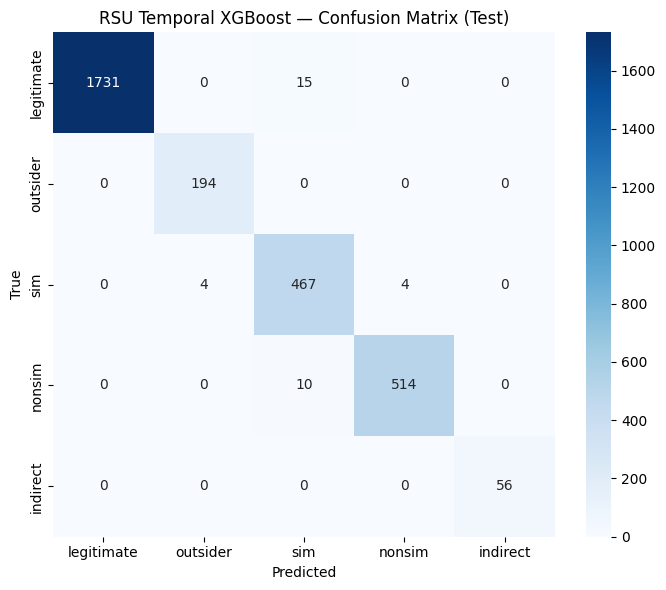


Top-15 feature importances:
speed_consistency_err_mean        0.112113
iat_entropy                       0.086753
claimed_id_beacons_seen_so_far    0.086589
active_claimed_ids_window         0.081033
pos_y_var                         0.073211
active_temp_ids_window            0.070299
new_claimed_ids_window            0.057126
aw_report_count_max               0.045817
n_beacons                         0.043379
obs_state_unverified_mean         0.037759
iat_min                           0.029390
iat_max                           0.025078
aw_rssi_unverified_count_max      0.022240
msg_count_span                    0.021490
iat_mean                          0.020458
dtype: float32


In [20]:
import xgboost as xgb
from sklearn.metrics import matthews_corrcoef, f1_score, accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

def make_xgb(max_depth):
    return xgb.XGBClassifier(
        objective="multi:softprob", num_class=len(ATTACK_CLASSES), eval_metric="mlogloss",
        max_depth=max_depth, learning_rate=XGB_LR, n_estimators=XGB_N_EST,
        subsample=0.8, colsample_bytree=0.8, min_child_weight=4,
        reg_lambda=1.0, reg_alpha=0.1, random_state=RANDOM_SEED,
        tree_method="hist", early_stopping_rounds=XGB_EARLY_STOP)

def xgb_proba_full(m, X):
    proba = m.predict_proba(X)
    full  = np.zeros((len(X), len(ATTACK_CLASSES)), dtype=float)
    for j, cls in enumerate(m.classes_):
        full[:, int(cls)] = proba[:, j]
    return full

def xgb_predict(m, X):
    return xgb_proba_full(m, X).argmax(axis=1)

# Sensitivity sweep over max_depth (paper §4.10.5)
best_model, best_depth, best_val_mcc = None, None, -1.0
print("max_depth sensitivity sweep:")
for depth in SWEEP_MAX_DEPTH:
    m = make_xgb(depth)
    m.fit(Xtr, ytr, sample_weight=sw, eval_set=[(Xva, yva)], verbose=False)
    vmcc = matthews_corrcoef(yva, xgb_predict(m, Xva))
    print(f"  max_depth={depth}: val MCC={vmcc:.4f}  best_iter={m.best_iteration}")
    if vmcc > best_val_mcc:
        best_model, best_depth, best_val_mcc = m, depth, vmcc

rsu_xgb = best_model
print(f"\nSelected max_depth={best_depth} (val MCC={best_val_mcc:.4f})")

y_pred = xgb_predict(rsu_xgb, Xte)
test_mcc = matthews_corrcoef(yte, y_pred)
test_acc = accuracy_score(yte, y_pred)
test_f1  = f1_score(yte, y_pred, average="macro", zero_division=0)
print(f"\n=== RSU XGBoost Test === MCC={test_mcc:.4f}  Acc={test_acc:.4f}  F1={test_f1:.4f}")
print("\n" + classification_report(yte, y_pred, target_names=ATTACK_CLASSES,
                                     labels=list(range(len(ATTACK_CLASSES))),
                                     digits=3, zero_division=0))

# Confusion matrix
cm = confusion_matrix(yte, y_pred, labels=list(range(len(ATTACK_CLASSES))))
fig, ax = plt.subplots(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=ATTACK_CLASSES, yticklabels=ATTACK_CLASSES, ax=ax)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title("RSU Temporal XGBoost — Confusion Matrix (Test)")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "rsu_temporal_xgb_cm.png"), dpi=150)
plt.show()

# Feature importances
importances = pd.Series(rsu_xgb.feature_importances_, index=cols).sort_values(ascending=False)
print("\nTop-15 feature importances:")
print(importances.head(15))

## 10. Export p_bar_temp and All Outputs

### p_bar_temp
`p_bar_temp(v_i) = 1 - p_legitimate(v_i)`

This is the RSU-tier Sybil suspicion score. High p_bar_temp = XGBoost thinks this identity is Sybil.
It feeds into the ensemble fusion equation at the RSU tier:

`y_hat_ens = λ1 * y_hat_i + λ2 * p_bar_temp + λ3 * p_bar_RSSI`

### Outputs
- `rsu_temporal_xgb.json` — saved model (load with XGBClassifier.load_model)
- `rsu_temporal_xgb_scores.csv` — per-window p_bar_temp scores for ensemble fusion
- `temporal_v2_windows.csv` — full feature table for LLM dataset construction

### NS-3 alignment: how this runs at deployment
At runtime, the RSU collects 5-second windows of beacon data, computes these same features,
and runs XGBoost inference to get p_bar_temp per claimed identity. This runs on the RSU server,
not on any vehicle OBU.

In [21]:
# Apply to all windows (train+val+test)
_Xa = pd.DataFrame(imputer.transform(feature_df_rsu[FEATURE_COLS]), columns=cols)
_Xs = pd.DataFrame(scaler_xgb.transform(_Xa), columns=cols)
_pro = xgb_proba_full(rsu_xgb, _Xs)
_pi  = _pro.argmax(axis=1)
_leg = CLASS_TO_IDX["legitimate"]

split_rsu = np.array(["train"] * len(feature_df_rsu), dtype=object)
split_rsu[val_idx]  = "val"
split_rsu[test_idx] = "test"

# (a) Per-window suspicion scores for ensemble fusion
rsu_scores = pd.DataFrame({
    "claimed_node_id": feature_df_rsu["claimed_node_id"].values,
    "window_start":    feature_df_rsu["window_start"].values,
    "window_end":      feature_df_rsu["window_end"].values,
    "true":            feature_df_rsu["attack_type"].values,
    "pred":            [IDX_TO_CLASS[i] for i in _pi],
    "p_legitimate":    _pro[:, _leg],
    "p_bar_temp":      1.0 - _pro[:, _leg],
    "split":           split_rsu,
})
rsu_xgb.save_model(os.path.join(OUTPUT_DIR, "rsu_temporal_xgb.json"))
rsu_scores.to_csv(os.path.join(OUTPUT_DIR, "rsu_temporal_xgb_scores.csv"), index=False)
print("Saved rsu_temporal_xgb.json + rsu_temporal_xgb_scores.csv", rsu_scores.shape)

# (b) Full window table for LLM dataset construction
exp = feature_df_rsu[["claimed_node_id","window_start","window_end"] + list(FEATURE_COLS)].copy()
exp["true"] = feature_df_rsu["attack_type"].values
exp["pred"] = [IDX_TO_CLASS[i] for i in _pi]
for j, c in enumerate(ATTACK_CLASSES):
    exp[f"p_{c}"] = _pro[:, j]
exp["p_bar_temp"] = 1.0 - _pro[:, _leg]
exp["split"] = split_rsu
out_path = os.path.join(OUTPUT_TEMPORAL_DIR, "temporal_v2_windows.csv")
exp.to_csv(out_path, index=False)
print("Saved temporal_v2_windows.csv", exp.shape)

print("\nSample p_bar_temp distribution:")
print(rsu_scores.groupby("true")["p_bar_temp"].describe()[["mean","min","max"]])

Saved rsu_temporal_xgb.json + rsu_temporal_xgb_scores.csv (20341, 8)
Saved temporal_v2_windows.csv (20341, 58)

Sample p_bar_temp distribution:
                mean       min       max
true                                    
indirect    0.999862  0.997208  0.999988
legitimate  0.005620  0.000010  0.999092
nonsim      0.999420  0.388171  0.999999
outsider    0.999354  0.965750  0.999998
sim         0.997190  0.691105  0.999981


## 11. Final Summary and NS-3 Integration Guide

### Results summary
This cell prints a clean summary of what was produced and how it connects to the full pipeline.

### NS-3 integration — what you need to do
To make this work end-to-end with live NS-3 simulation:

1. **RSU logging** — your NS-3 RSU application (`rsu-edge-app.cc`) must write:
   - `communication_log.csv` with `receiver_role` and `flow` columns (already done ✅)
   - `rsu_regional_awareness_log.csv` — per-identity RSSI verification summary
   - `rsu_vehicle_observation_rows_log.csv` — per-observation RSSI state rows
   If these logs don't exist, RSSI awareness features will be zeros — model still works but weaker.

2. **Inference at runtime** — load `rsu_temporal_xgb.json` on the RSU server,
   compute the same 5-second window features, call `predict_proba`, return `p_bar_temp`.

3. **Ensemble fusion** — `rsu_ensemble_fusion.py` (separate script) combines:
   `y_hat_ens = λ1 * y_hat_i + λ2 * p_bar_temp + λ3 * p_bar_RSSI`
   where y_hat_i comes from GRU notebook, p_bar_RSSI from RSSI XGBoost notebook.

In [22]:
print("=" * 65)
print("TEMPORAL XGBoost v2 — RSU TIER — RESULTS SUMMARY")
print("=" * 65)
print(f"  max_depth selected:  {best_depth}  (val MCC = {best_val_mcc:.4f})")
print(f"  Test MCC:            {test_mcc:.4f}")
print(f"  Test Accuracy:       {test_acc:.4f}")
print(f"  Test F1-macro:       {test_f1:.4f}")
print(f"  Features used:       {len(cols)} ({len(BEHAVIOURAL_COLS)} behavioural + {len(AWARE_COLS)} RSSI awareness)")
print(f"  Training windows:    {len(train_idx):,}")
print()
print("Outputs written to:", OUTPUT_DIR)
print("  rsu_temporal_xgb.json          — model")
print("  rsu_temporal_xgb_scores.csv    — p_bar_temp per window")
print("  rsu_temporal_xgb_cm.png        — confusion matrix")
print()
print(OUTPUT_TEMPORAL_DIR)
print("  temporal_v2_windows.csv        — full feature table + p_bar_temp")
print()
print("Next step: run rsu_ensemble_fusion.py to combine")
print("  y_hat_i (from GRU) + p_bar_temp + p_bar_RSSI → y_hat_ens")
print("=" * 65)

TEMPORAL XGBoost v2 — RSU TIER — RESULTS SUMMARY
  max_depth selected:  4  (val MCC = 0.9822)
  Test MCC:            0.9818
  Test Accuracy:       0.9890
  Test F1-macro:       0.9876
  Features used:       46 (31 behavioural + 14 RSSI awareness)
  Training windows:    14,708

Outputs written to: /home/sdvn_defense_sybil/35_sybil_attack_project/ns-allinone-3.35/ns-3.35/sybil-attack/ml/outputs
  rsu_temporal_xgb.json          — model
  rsu_temporal_xgb_scores.csv    — p_bar_temp per window
  rsu_temporal_xgb_cm.png        — confusion matrix

/home/sdvn_defense_sybil/35_sybil_attack_project/ns-allinone-3.35/ns-3.35/sybil-attack/ml/outputs_temporal
  temporal_v2_windows.csv        — full feature table + p_bar_temp

Next step: run rsu_ensemble_fusion.py to combine
  y_hat_i (from GRU) + p_bar_temp + p_bar_RSSI → y_hat_ens


## 12. Window-Size Sensitivity Sweep (paper §4.10.5)

The deployed model uses a single 5-second window (Section 1). This section resolves that choice
empirically: it sweeps the RSU **time window over {2s, 5s, 10s}** and validates each against its
**beacon-count equivalent W ∈ {5, 10, 20}** — the count-based windowing used by the OBU / GRU
tier — so the two schemes cross-check each other.

### Design (leakage-safe, non-destructive)
- **Behavioural features only** (no RSSI merge): the RSSI awareness join is independent of window
  geometry, so excluding it keeps the two windowings comparable on geometry alone.
- Each config runs the full pipeline — grouped split by `claimed_node_id` → median impute →
  standard-scale → XGBoost at a **fixed `max_depth`** (the value chosen in Section 9) — which
  isolates the window-size effect as a controlled one-factor experiment.
- Nothing here overwrites `feature_df_rsu`, the deployed split/model, or any exported artifact;
  it only writes `temporal_xgb_window_sensitivity.csv` / `.png`.

### How to read it
`time_test_mcc` and `count_test_mcc` should track each other down each paired row
(2s ↔ W5, 5s ↔ W10, 10s ↔ W20). A small `abs_test_mcc_gap` means the time-based sweep is
corroborated by its beacon-count equivalents. The `mean_beacons` columns report how many beacons
each window actually spans.

**Note:** this sweep is slow (6 feature builds + 6 XGBoost fits). Run it when validating the
window choice, not on every training pass.

In [ ]:
# ── Window-size sensitivity sweep (paper §4.10.5) ─────────────────────────────
# Sweep the RSU time-window over {2s, 5s, 10s} AND validate each against its
# beacon-count equivalent W ∈ {5, 10, 20} (the count-based windowing the OBU/GRU
# tier uses). SELF-CONTAINED: uses only local variables and never touches
# feature_df_rsu, the deployed split, the fitted model, or any exported artifact.
# Behavioural features only (no RSSI merge) so the two windowings are compared
# apples-to-apples on window geometry alone.

def build_feature_table_count(beacons_df, W, step_beacons, min_beacons=MIN_BEACONS_WINDOW):
    """Count-based analogue of build_feature_table: slide W-beacon windows per
    claimed_node_id (stride step_beacons), computing the SAME 31 behavioural
    features. Cross-identity context is measured over each window's actual
    [t0, t1] span, exactly as the time builder measures it over [s, s+window)."""
    b = beacons_df.sort_values("receive_time").reset_index(drop=True)
    t_all   = b["receive_time"].values
    cid_all = b["claimed_node_id"].values
    tid_all = b["bsm_temporary_id"].values
    first_seen_arr = b.groupby("claimed_node_id")["receive_time"].min().values

    def _ctx(s, e):
        lo = np.searchsorted(t_all, s, side="left")
        hi = np.searchsorted(t_all, e, side="right")
        if hi <= lo:
            return (0, 0, 0, 0, 0)
        c = cid_all[lo:hi]; ti = tid_all[lo:hi]
        uniq_t, inv = np.unique(ti, return_inverse=True)
        shared = 0; maxc = 0
        for k in range(uniq_t.size):
            uc = int(np.unique(c[inv == k]).size)
            if uc > 1: shared += 1
            if uc > maxc: maxc = uc
        new_ids = int(((first_seen_arr >= s) & (first_seen_arr <= e)).sum())
        return (int(np.unique(c).size), int(uniq_t.size), shared, maxc, new_ids)

    rows = []
    for cidv, g in b.groupby("claimed_node_id", sort=False):
        g  = g.sort_values("receive_time")
        rt = g["receive_time"].values
        n  = len(rt)
        if n < min_beacons:
            continue
        gx = g["bsm_x"].values;   gy = g["bsm_y"].values
        gsp = g["bsm_speed"].values; ghd = g["bsm_heading"].values
        gtid = g["bsm_temporary_id"].values; gmsg = g["bsm_msg_count"].values
        gpsz = g["packet_size"].values; gdly = g["delay"].values
        gobs = g["observer_count"].values
        gacl = g["attack_class"].values; gisy = g["is_sybil"].values.astype(int)
        fs = float(rt[0])
        prev_end = None
        for start in range(0, max(n - W + 1, 1), step_beacons):
            end = min(start + W, n)
            nb_ = end - start
            if nb_ < min_beacons:
                continue
            sl = slice(start, end)
            wt = rt[sl]
            s = float(wt[0]); e = float(wt[-1]); span = max(e - s, 1e-9)
            iats = np.diff(wt)
            wtid = gtid[sl].astype(str)
            tch  = int((wtid[1:] != wtid[:-1]).sum()) if nb_ > 1 else 0
            gap  = (s - prev_end) if prev_end is not None else 0.0
            wx = gx[sl]; wy = gy[sl]; wsp = gsp[sl]; whd = ghd[sl]
            dx = np.diff(wx); dy = np.diff(wy)
            exp_dx = wsp[:-1] * np.cos(np.radians(whd[:-1])) * iats
            exp_dy = wsp[:-1] * np.sin(np.radians(whd[:-1])) * iats
            speed_err = float(np.sqrt((dx - exp_dx) ** 2 + (dy - exp_dy) ** 2).mean()) if len(dx) else 0.0
            wmsg = gmsg[sl]
            ac, at, st_, mc, ni = _ctx(s, e)
            vals, cnts = np.unique(gacl[sl], return_counts=True)
            attack_type = vals[cnts.argmax()]
            is_sybil = int(np.bincount(gisy[sl]).argmax())
            rows.append({
                "claimed_node_id": cidv, "window_start": s, "window_end": e,
                "attack_type": attack_type, "is_sybil": is_sybil,
                "n_beacons": nb_,
                "n_distinct_temp_ids": int(np.unique(gtid[sl]).size),
                "temp_id_churn_rate": tch / max(nb_ - 1, 1),
                "temp_id_change_count": tch,
                "claimed_id_age_s": s - fs,
                "claimed_id_beacons_seen_so_far": int(end),
                "iat_mean": float(np.mean(iats)) if len(iats) else 0.0,
                "iat_std":  float(np.std(iats))  if len(iats) else 0.0,
                "iat_min":  float(np.min(iats))  if len(iats) else 0.0,
                "iat_max":  float(np.max(iats))  if len(iats) else 0.0,
                "iat_entropy": shannon_entropy(iats),
                "gap_since_prev_window": gap,
                "beacon_rate_hz": nb_ / span,
                "pos_x_var": float(np.var(wx, ddof=1)),
                "pos_y_var": float(np.var(wy, ddof=1)),
                "speed_mean": float(np.mean(wsp)),
                "speed_std":  float(np.std(wsp)),
                "heading_std": float(np.std(whd, ddof=1)),
                "speed_consistency_err_mean": speed_err,
                "packet_size_mean": float(np.mean(gpsz[sl])),
                "delay_mean": float(np.mean(gdly[sl])),
                "delay_std":  float(np.std(gdly[sl], ddof=1)),
                "observer_count_mean": float(np.mean(gobs[sl])),
                "observer_count_std":  float(np.std(gobs[sl], ddof=1)),
                "msg_count_span": int(wmsg.max() - wmsg.min()) if len(wmsg) > 1 else 0,
                "msg_count_reset_flag": int((np.diff(wmsg) < 0).any()) if len(wmsg) > 1 else 0,
                "active_claimed_ids_window": ac,
                "active_temp_ids_window": at,
                "shared_temp_id_count_window": st_,
                "max_claimed_per_temp_id_window": mc,
                "new_claimed_ids_window": ni,
            })
            prev_end = e
    return pd.DataFrame(rows)


def _evaluate_windowing(fdf, label, depth):
    """Behavioural-only pipeline: grouped split -> median impute -> scale ->
    XGBoost at a FIXED max_depth -> val/test MCC. Fixed depth isolates the
    window-size effect (controlled one-factor experiment)."""
    X   = fdf[BEHAVIOURAL_COLS].copy()
    y   = fdf["attack_type"].map(CLASS_TO_IDX).values
    grp = ("c_" + fdf["claimed_node_id"].astype(str)).values
    tr, va, te, _seed, cov = grouped_split(X, y, grp, TEST_SIZE, VAL_SIZE, RANDOM_SEED)
    imp = SimpleImputer(strategy="median", keep_empty_features=True)
    sc  = StandardScaler()
    Xtr_ = sc.fit_transform(imp.fit_transform(X.iloc[tr]))
    Xva_ = sc.transform(imp.transform(X.iloc[va]))
    Xte_ = sc.transform(imp.transform(X.iloc[te]))
    sw_  = compute_sample_weight("balanced", y[tr])
    m = make_xgb(depth)
    m.fit(Xtr_, y[tr], sample_weight=sw_, eval_set=[(Xva_, y[va])], verbose=False)
    pva = xgb_predict(m, Xva_); pte = xgb_predict(m, Xte_)
    return {
        "config": label, "n_windows": len(fdf),
        "mean_beacons": float(fdf["n_beacons"].mean()),
        "depth": depth, "coverage": bool(cov),
        "val_mcc":  matthews_corrcoef(y[va], pva),
        "test_mcc": matthews_corrcoef(y[te], pte),
        "test_f1":  f1_score(y[te], pte, average="macro", zero_division=0),
    }


# Paired configs: time {2,5,10}s  <->  beacon-count {5,10,20}. Time steps keep the
# same 40% overlap as the deployed 5s/2s setting; count steps mirror that ratio.
SWEEP_WINDOW_S      = [2.0, 5.0, 10.0]
SWEEP_WINDOW_STEP_S = [0.8, 2.0, 4.0]
SWEEP_WINDOW_W      = [5, 10, 20]
SWEEP_WINDOW_W_STEP = [2, 4, 8]
_swp_depth = int(globals().get("best_depth", 5))
print(f"Window-size sensitivity sweep (fixed max_depth={_swp_depth}). "
      f"Slow: 6 feature builds + 6 XGBoost fits.\n")

_time_rows, _count_rows = [], []
for _ws, _wstep in zip(SWEEP_WINDOW_S, SWEEP_WINDOW_STEP_S):
    _fdf = build_feature_table(rsu_beacons, window_size=_ws, window_step=_wstep)
    _r = _evaluate_windowing(_fdf, f"time_{_ws:g}s", _swp_depth)
    _time_rows.append(_r)
    print(f"  time  {_ws:g}s: windows={_r['n_windows']:>6}  mean_beacons={_r['mean_beacons']:5.1f}  "
          f"val MCC={_r['val_mcc']:.4f}  test MCC={_r['test_mcc']:.4f}")
for _W, _wst in zip(SWEEP_WINDOW_W, SWEEP_WINDOW_W_STEP):
    _fdf = build_feature_table_count(rsu_beacons, W=_W, step_beacons=_wst)
    _r = _evaluate_windowing(_fdf, f"count_W{_W}", _swp_depth)
    _count_rows.append(_r)
    print(f"  count W{_W:>2}: windows={_r['n_windows']:>6}  mean_beacons={_r['mean_beacons']:5.1f}  "
          f"val MCC={_r['val_mcc']:.4f}  test MCC={_r['test_mcc']:.4f}")

_time_df  = pd.DataFrame(_time_rows)
_count_df = pd.DataFrame(_count_rows)

window_sensitivity = pd.DataFrame({
    "time_window":        [f"{w:g}s" for w in SWEEP_WINDOW_S],
    "beacon_equiv_W":     SWEEP_WINDOW_W,
    "time_mean_beacons":  _time_df["mean_beacons"].round(1).values,
    "count_mean_beacons": _count_df["mean_beacons"].round(1).values,
    "time_val_mcc":       _time_df["val_mcc"].round(4).values,
    "count_val_mcc":      _count_df["val_mcc"].round(4).values,
    "time_test_mcc":      _time_df["test_mcc"].round(4).values,
    "count_test_mcc":     _count_df["test_mcc"].round(4).values,
    "abs_test_mcc_gap":   np.abs(_time_df["test_mcc"].values - _count_df["test_mcc"].values).round(4),
})
window_sensitivity.to_csv(os.path.join(OUTPUT_DIR, "temporal_xgb_window_sensitivity.csv"), index=False)
print("\n" + window_sensitivity.to_string(index=False))

_best_i = int(_time_df["val_mcc"].values.argmax())
print(f"\nBest time window by val MCC: {SWEEP_WINDOW_S[_best_i]:g}s "
      f"(val MCC={_time_df['val_mcc'].iloc[_best_i]:.4f}, "
      f"test MCC={_time_df['test_mcc'].iloc[_best_i]:.4f})")
print(f"Deployed window (Section 1): {WINDOW_SIZE_S:g}s / {WINDOW_STEP_S:g}s step")
print(f"Max |time - count| test-MCC gap across paired sizes: "
      f"{window_sensitivity['abs_test_mcc_gap'].max():.4f}  "
      f"(small gap => the time sweep is corroborated by its beacon-count equivalents)")

fig, ax = plt.subplots(figsize=(7.5, 4))
_xa = np.arange(len(SWEEP_WINDOW_S))
ax.plot(_xa, _time_df["test_mcc"],  "o-",  lw=1.8, label="time-based {2,5,10}s")
ax.plot(_xa, _count_df["test_mcc"], "s--", lw=1.8, label="count-based W{5,10,20}")
ax.set_xticks(_xa)
ax.set_xticklabels([f"{w:g}s\nW{W}" for w, W in zip(SWEEP_WINDOW_S, SWEEP_WINDOW_W)])
ax.set_xlabel("window size  (time  /  beacon-count equivalent)")
ax.set_ylabel("Test MCC")
ax.set_title(f"RSU XGBoost — window-size sensitivity (fixed max_depth={_swp_depth})")
ax.legend(); ax.grid(True, alpha=0.3); plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "temporal_xgb_window_sensitivity.png"), dpi=150)
plt.show()
print("\nSaved temporal_xgb_window_sensitivity.csv + .png to", OUTPUT_DIR)